# Encoding the Audio

In [3]:
import sys 
import os 
import pickle 
import numpy as np
import spacy
import seaborn as sns
import matplotlib as plt 
import matplotlib.pyplot as plt 
import pandas as pd

sys.path.append(os.path.abspath("../lingpred_new/"))
from plotting import times_100, lowerCI, upperCI, reshape, colours
from encoding_analysis import make_arbitrary_static_vectors, brainscore
from utils import get_words_onsets_offsets, get_bigram_mask, make_y_matrix_per_run, get_runs, subsample_to_adjust_PoS

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [31]:
# select the dataset:
# -------------------
# dataset = 'Goldstein' # or 
dataset = 'Armeni'
#dataset = 'Gwilliams'

# type of audio data:
use_real_word_offsets = True

if not use_real_word_offsets:
    print('This will use the onset of the next word as the offset of the current word.')
    print('Beware that this will result in poor acoustic representations as it will include silences between words.')
    print('We only recommend using this for comparision with the Gwilliams dataset.')

# dummy variables needed for that get_run functions
session = 1
subject = 1
if dataset == 'Gwilliams':
    tasks   = ['0', '1', '2', '3']
else:
    tasks   = ['0']

if dataset == 'Armeni':
    sessions = np.arange(1, 11)
else:
    sessions = [1]

# Let's get the dataframe containing the words:
words_df = pd.DataFrame()

for session in sessions:
    for task in tasks:
        runs     = get_runs(dataset, session, subject, task) 
        for run in runs:
            if len(runs)==1:
                words_df = get_words_onsets_offsets(dataset, subject=subject, session=session, run=run, task=task)
            else: 
                temp     = get_words_onsets_offsets(dataset, subject=subject, session=session, run=run, task=task)
                words_df = pd.concat([words_df, temp])
            
len(words_df)

85719

In [32]:
# load the appropriate acoustic model:
if dataset == 'Gwilliams':
    use_real_word_offsets = False # for Gwilliams there is no information on word offsets

if use_real_word_offsets:     
    with open('../audio/{}/acoustic_model_8_mels_averaged_per_word_using_word_offsets.pkl'.format(dataset), 'rb') as f:
        acoustics = pickle.load(f)
else:   
    with open('../audio/{}/acoustic_model_8_mels_averaged_per_word_using_next_word_onset_as_offset.pkl'.format(dataset), 'rb') as f:
        acoustics = pickle.load(f)

acoustics.shape

(85719, 9)

In [33]:
# Compute the indices for making the y matrix
# -------------------------------------------
# This is already saved under audio/<dataset>/indices.pkl
# No need to run this again, as this would take  approx. 10 min

'''
from utils import get_indices_per_task
indices = get_indices_per_task(dataset) # For Armeni/Gwilliams, need to loop over sessions/tasks
indices.shape

dir_path = '../audio/{}/'.format(dataset)
if dataset == 'Goldstein':
    file_name = 'indices.pkl'
path      = dir_path + file_name

print(path)
f = open(path,"wb")
pickle.dump(indices, f)
f.close()
'''

# load the indices:
if dataset == 'Goldstein':
    with open(f'../audio/{dataset}/indices.pkl', 'rb') as f:
        indices = pickle.load(f)
elif dataset == 'Gwilliams':
    with open(f'../audio/{dataset}/indices_all_tasks.pkl', 'rb') as f:
        indices = pickle.load(f)
elif dataset == 'Armeni':
    with open(f'../audio/{dataset}/indices_all_sessions.pkl', 'rb') as f:
        indices = pickle.load(f)


indices.shape

(85719, 157)

In [34]:
# make sure they are integers:
indices = indices.astype(int)

In [35]:
# use indices to make an acoustic y matrix of shape (length, 157, dim)
y_acoustics = make_y_matrix_per_run(acoustics, indices)
print('Acoustic y matrix of shape (length, 157, dimensionality)')
y_acoustics.shape

Acoustic y matrix of shape (length, 157, dimensionality)


(85719, 157, 9)

In [36]:
# Let us look at what our words dataframe looks like at the moment:
words_df.head(6)

,onset,duration,sample,type,word,offset
3,1.089189,0.129705,46637.372038,word_onset_01,THE,1.218895
6,1.218895,0.678458,46793.018296,word_onset_01,ADVENTURES,1.897353
15,1.897353,0.089796,47607.167956,word_onset_01,OF,1.987149
18,1.987149,0.488889,47714.923058,word_onset_01,SHERLOCK,2.476037
24,2.476037,0.698413,48301.589725,word_onset_01,HOLMES,3.174450
31,3.912772,0.149660,50025.671358,word_onset_01,A,4.062432


In [37]:
if dataset == 'Gwilliams': # contains the word 'None' and needs to be forced to string 
    words_df['word'] = words_df['word'].map(lambda x: str(x))


In [38]:
# make spacy doc of the text
nlp     = spacy.load('en_core_web_lg')
text    = " ".join(words_df["word"].astype(str))
doc     = nlp(text)

# since our doc is longer than our dataframe we have to match PoS to fit the dataframe
# (words like "there's" are two words in the doc but one in the dataframe)
matched_PoS = []
token_idx   = 0

for word in words_df['word']:
    # get the PoS of the current token
    if token_idx < len(doc):
        matched_PoS.append(doc[token_idx].pos_)
        # advance token_idx until the next word boundary
        token_idx += len(nlp(word))  # number of spaCy tokens in this word
    else:
        # fallback if doc ends unexpectedly
        matched_PoS.append(None)

len(matched_PoS), len(words_df)

(85719, 85719)

In [39]:
# amend the words dataframe with useful information:
words_df['duration']              = words_df['offset'] - words_df['onset']
words_df['duration previous word']= words_df['duration'].shift(1)
words_df['PoS']                   = matched_PoS
words_df['previous PoS']          = words_df['PoS'].shift(1)
words_df['word_index']            = np.arange(len(words_df)).astype(int)
words_df['word']                  = words_df['word'].astype('string')


# include information about the PoS type: content vs. non-content word:
content_pos = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV'}

def map_content(pos):
    return 'Content' if pos in content_pos else 'Non-content'

# Apply mapping
words_df['previous PoS_type']   = words_df['previous PoS'].apply(map_content)

# avoid having NaNs (for the first word the duration of the previous words is undefined)
words_df.iloc[0, words_df.columns.get_loc('duration previous word')] = 0

# Let us look at what our words dataframe looks like at the moment:
words_df.head(6)

,onset,duration,sample,type,word,offset,duration previous word,PoS,previous PoS,word_index,previous PoS_type
3,1.089189,0.129705,46637.372038,word_onset_01,THE,1.218895,0.000000,DET,None,0,Non-content
6,1.218895,0.678458,46793.018296,word_onset_01,ADVENTURES,1.897353,0.129705,PROPN,DET,1,Non-content
15,1.897353,0.089796,47607.167956,word_onset_01,OF,1.987149,0.678458,ADP,PROPN,2,Content
18,1.987149,0.488889,47714.923058,word_onset_01,SHERLOCK,2.476037,0.089796,PROPN,ADP,3,Non-content
24,2.476037,0.698413,48301.589725,word_onset_01,HOLMES,3.174450,0.488889,PROPN,PROPN,4,Content
31,3.912772,0.149660,50025.671358,word_onset_01,A,4.062432,0.698413,DET,PROPN,5,Content


### Getting the X Matrices: GPT, GloVe and Arbitrary vectors

In [40]:

# Make X matrices for arbitrary vectors        
X_arbitrary  = make_arbitrary_static_vectors(words_df, dim=300)

# Get GloVe vectors:
X_Glove = np.vstack([nlp(word).vector for word in words_df.word]) # np array of shape (nr_words, 300)

# Get GPT vectors:
if dataset == 'Goldstein':  
    with open('../audio/Goldstein/X_GPT_original_and_residualised_layer_47.pkl', 'rb') as f:
        X_matrices_GPT     = pickle.load(f)
        X_GPT              = X_matrices_GPT['X_GPT_layer_47']
elif dataset == 'Armeni':
    with open('../audio/Armeni/vectors_GPT_Glove_arbitrary_y_matrix_like_selfpred.pkl', 'rb') as f:
        X_matrices_GPT     = pickle.load(f)
        X_GPT              = X_matrices_GPT['X_GPT']
elif dataset == 'Gwilliams':
    with open('../data/Gwilliams/X_y_matrices_GPT_Glove_arbitrary.pkl', 'rb') as f:
        X_matrices_GPT     = pickle.load(f)
        X_GPT              = X_matrices_GPT['X_GPT']

print('Arbitrary vectors have shape:', X_arbitrary.shape)
print('GloVe vectors have shape:', X_Glove.shape)
print('GPT vectors have shape:', X_GPT.shape)

KeyError: 'X_GPT'

### Audio Encoding: Main Effect

In [12]:
reoccuring_bigram_mask = get_bigram_mask(words_df)
reoccuring_bigram_mask.shape

     word  onset  offset  duration  duration previous word    PoS  \
0     Act  3.710   3.790      0.08                    0.00  PROPN   
1    one,  3.990   4.190      0.20                    0.08    NUM   
2  monkey  4.651   4.931      0.28                    0.20   NOUN   
3      in  4.951   5.011      0.06                    0.28    ADP   
4     the  5.051   5.111      0.06                    0.06    DET   

  previous PoS  word_index previous PoS_type next_word       bigram  
0         None           0       Non-content      one,     Act_one,  
1        PROPN           1           Content    monkey  one,_monkey  
2          NUM           2       Non-content        in    monkey_in  
3         NOUN           3           Content       the       in_the  
4          ADP           4       Non-content   middle.  the_middle.  


(4110,)

In [13]:
# compute encoding for original GloVe and arbitrary vectors:
# ----------------------------------------------------------

# format the y matrix correctly:
y = y_acoustics
y = np.swapaxes(np.swapaxes(y, 0, 1), 0, 2)
print('y should be of shape: (nr_mels, nr_words, nr_timepoints')
print('y has shape ', y.shape)
print('-'*25)

# do encoding for 'full' vectors
encoding_arbitrary = brainscore(X_arbitrary, y)
encoding_Glove     = brainscore(X_Glove, y)
encoding_GPT       = brainscore(X_GPT, y)

# dropping the first row in the y matrix is done inside the brainscore_no_coef function, so we keep y as is
print('\n y should be of shape: (nr_mels, nr_words, nr_timepoints')
print('y has shape ', y.shape)
print('-'*25)

# do encoding for 'residual' vectors:
encoding_arbitrary_residualised = brainscore(X_arbitrary, y, residualise=True)
encoding_Glove_residualised     = brainscore(X_Glove, y, residualise=True)
encoding_GPT_residualised       = brainscore(X_GPT, y, residualise=True)

# format the y matrix correctly:
y = y_acoustics
y = np.swapaxes(np.swapaxes(y, 0, 1), 0, 2)
print('\n y should be of shape: (nr_mels, nr_words, nr_timepoints')
('y has shape ', y.shape)
print('-'*25)
encoding_arbitrary_no_bigrams = brainscore(X_arbitrary, y, indx_top_1=reoccuring_bigram_mask)

y should be of shape: (nr_mels, nr_words, nr_timepoints
y has shape  (9, 5136, 157)
-------------------------
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)

 y should be of shape: (nr_mels, nr_words, nr_timepoints
y has shape  (9, 5136, 157)
-------------------------
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)

 y should be of shape: (nr_mels, nr_words, nr_timepoints
-------------------------
We are now in the brainscore method, and y has shape:
(9, 5136, 157)


In [14]:
# Let's save the results with original vectors in one file:
directory = '../audio/{}/'.format(dataset)
file_name = 'vectors_GPT_Glove_arbitrary_y_matrix_like_selfpred.pkl'
path      = directory + file_name
print(path)

keys    = ['corr_GPT', 'corr_Glove', 'corr_Arbitrary']
values  = [encoding_GPT, encoding_Glove, encoding_arbitrary]
results = dict(zip(keys, values))

f = open(path,"wb")
pickle.dump(results, f)
f.close()


# Let's save the regressed out result in one file:
directory = '../audio/{}/'.format(dataset)
file_name = 'regressed_out_vectors_Glove_arbitrary_y_matrix_like_selfpred.pkl'
path      = directory + file_name
print(path)

keys    = ['corr_GPT','corr_Glove', 'corr_Arbitrary']
values  = [encoding_GPT_residualised, encoding_Glove_residualised, encoding_arbitrary_residualised]
res_results = dict(zip(keys, values))

f = open(path,"wb")
pickle.dump(res_results, f)
f.close()


fig_path    = 'Acoustics_without_reoccuring_bigrams_with_original_vectors_{}.pkl'.format(dataset)
path        = directory + fig_path
keys        = ['corr_Arbitrary']
values      = [encoding_arbitrary]
nobigram_results = dict(zip(keys, values))

f = open(path,"wb")
pickle.dump(nobigram_results, f)
f.close()
print(path)

../audio/Goldstein/vectors_GPT_Glove_arbitrary_y_matrix_like_selfpred.pkl
../audio/Goldstein/regressed_out_vectors_Glove_arbitrary_y_matrix_like_selfpred.pkl
../audio/Goldstein/Acoustics_without_reoccuring_bigrams_with_original_vectors_Goldstein.pkl


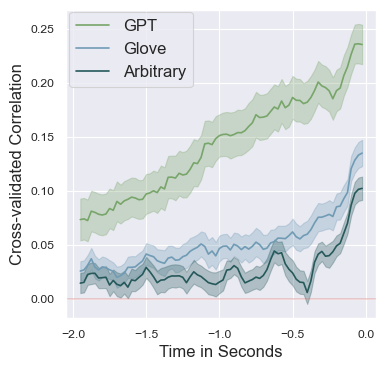

In [16]:
# get model names
models = [k.split(sep='_')[1] for k in results.keys()]
labels = [m for m in models]
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate(results.keys()):
    ax1.plot(times_100[:78], results[key].mean(axis=0).mean(axis=0)[:78], c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100[:78], lowerCI(reshape(results[key]))[:78], 
                                upperCI(reshape(results[key]))[:78], color=colours[models[i]], alpha=0.3)

ax1.legend(loc=(0.01,0.75), fontsize=12)
#ax1.set_ylim([-0.005, 0.05])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
#ax1.set_title(dataset+': Audio Encoding based on Original Vectors')

fig_folder = '../figures/supplementary/'

use_regressed_out= False
plot_split = False
top = 1

fig_path = fig_folder+'Acoustics_{}_with_residualised_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)

#plt.savefig(fig_path, format='pdf',bbox_inches='tight')

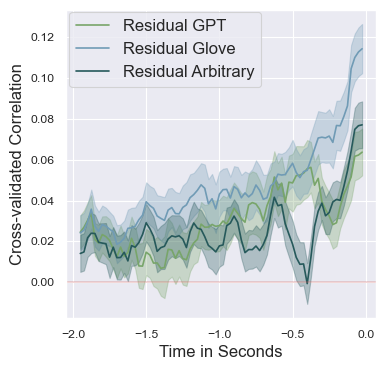

In [17]:
# get model names
models = [k.split(sep='_')[1] for k in results.keys()]
labels = ['Residual ' + m for m in models]
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate(res_results.keys()):
    ax1.plot(times_100[:78], res_results[key].mean(axis=0).mean(axis=0)[:78], c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100[:78], lowerCI(reshape(res_results[key]))[:78], 
                                upperCI(reshape(res_results[key]))[:78], color=colours[models[i]], alpha=0.3)

ax1.legend(loc=(0.01,0.75), fontsize=12)
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
#ax1.set_title(dataset+': Audio Encoding based on Residualised Vectors')

use_regressed_out= True
plot_split = False
top = 1

fig_path = fig_folder+'Acoustics_{}_with_residualised_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)

#plt.savefig(fig_path, format='pdf',bbox_inches='tight')

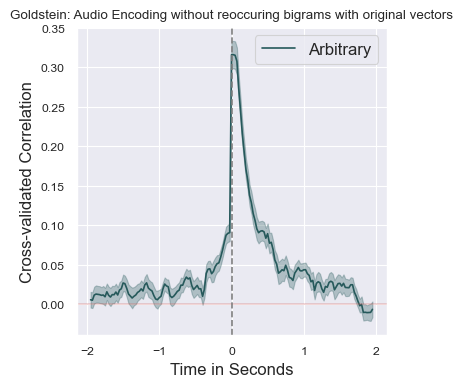

In [ ]:
# get model names
models = ['Arbitrary']
labels = models
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_arbitrary_no_bigrams]):
    ax1.plot(times_100, key.mean(axis=0).mean(axis=0), c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100, lowerCI(reshape(key)), 
                                upperCI(reshape(key)), color=colours[models[i]], alpha=0.3)

ax1.legend( fontsize=12)
#ax1.set_ylim([-0.005, 0.05])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
ax1.set_title(dataset+': Audio Encoding without reoccuring bigrams with original vectors')

#add dashed vertical line at t=0:
ax1.axvline(x=0, color='gray', linestyle='--')

fig_folder = '../figures/supplementary/'

use_regressed_out = False
plot_split        = False
top               = None

fig_path = fig_folder+'Acoustics_without_reoccuring_bigrams_with_original_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)

plt.savefig(fig_path, format='pdf',bbox_inches='tight')

### Audio Encoding: The Predictability Effect

In [41]:
# Let's get the information about top predictions:
# ------------------------------------------------

if dataset == 'Goldstein':
    df = pd.read_csv('../Goldstein_gpt_features/transcript_data_gpt.txt', 
                                sep='\t',
                                index_col='Unnamed: 0')
    # first we only want to keep the word-initial token of a word:
    mask_first = df["word_idx"] != df["word_idx"].shift(1)
    df_first   = df[mask_first]

    is_top_1     = [x < 1 for x in df_first['rank']] # rank 0 is the Top-1 prediction
    is_not_top_1 = [not x for x in is_top_1]
    is_top_5     = [x < 5 for x in df_first['rank']] # rank 4 is the Top-5 prediction
    is_not_top_5 = [not x for x in is_top_5]

if dataset in ['Armeni', 'Gwilliams']:
    with open(f'../audio/{dataset}/Dataframe_WordSurprisal_Top10Words_All_Sessions.pkl', 'rb') as f:
        df = pickle.load(f)
    is_top_1 = df.is_Top_1.to_list()[:X_Glove.shape[0]]
    is_not_top_1 = [not x for x in is_top_1]
    is_top_5     = df.is_Top_5.to_list()[:X_Glove.shape[0]]
    is_not_top_5 = [not x for x in is_top_5]

print('Top-1:', np.unique(is_top_1, return_counts=True))
print('Top-5:', np.unique(is_top_5, return_counts=True))

Top-1: (array([False,  True]), array([55129, 30590]))
Top-5: (array([False,  True]), array([35053, 50666]))


In [42]:
# Let's add this information to our words dataframe:
words_df['is_top_1'] = is_top_1
words_df['is_top_5'] = is_top_5

words_df['previous word'] = words_df['word'].shift(1)
words_df.iloc[0, words_df.columns.get_loc('previous word')] = ''
words_df['previous bigram'] = words_df['previous word'] + '_' + words_df['word']
words_df['is_bigram'] = words_df.duplicated('previous bigram', keep=False)

if dataset == 'Gwilliams':
    words_df = words_df.reset_index()
words_df.head(6)

,onset,duration,sample,type,word,offset,duration previous word,PoS,previous PoS,word_index,previous PoS_type,is_top_1,is_top_5,previous word,previous bigram,is_bigram
3,1.089189,0.129705,46637.372038,word_onset_01,THE,1.218895,0.000000,DET,None,0,Non-content,True,True,,_THE,False
6,1.218895,0.678458,46793.018296,word_onset_01,ADVENTURES,1.897353,0.129705,PROPN,DET,1,Non-content,False,False,THE,THE_ADVENTURES,False
15,1.897353,0.089796,47607.167956,word_onset_01,OF,1.987149,0.678458,ADP,PROPN,2,Content,True,True,ADVENTURES,ADVENTURES_OF,True
18,1.987149,0.488889,47714.923058,word_onset_01,SHERLOCK,2.476037,0.089796,PROPN,ADP,3,Non-content,False,False,OF,OF_SHERLOCK,True
24,2.476037,0.698413,48301.589725,word_onset_01,HOLMES,3.174450,0.488889,PROPN,PROPN,4,Content,True,True,SHERLOCK,SHERLOCK_HOLMES,True
31,3.912772,0.149660,50025.671358,word_onset_01,A,4.062432,0.698413,DET,PROPN,5,Content,False,False,HOLMES,HOLMES_A,True


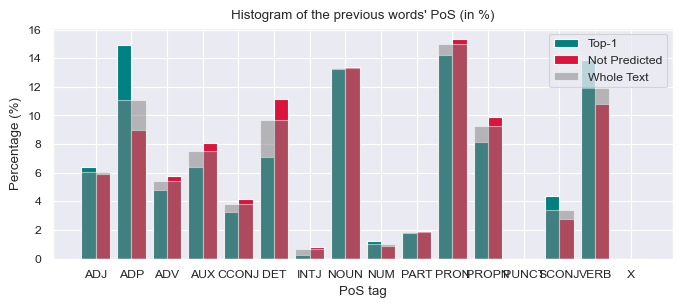

In [43]:

# Count and sort alphabetically, then convert to percentages
counts_top1     = words_df[words_df.is_top_1]['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts_not_top1 = words_df[~words_df.is_top_1]['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts_all      = words_df['previous PoS'].value_counts(normalize=True).sort_index() * 100

# Combine the index to cover all POS tags
all_tags = counts_top1.index.union(counts_not_top1.index).union(counts_all.index)
# Reindex to include all tags, filling missing with 0
counts_top1     = counts_top1.reindex(all_tags, fill_value=0)
counts_not_top1 = counts_not_top1.reindex(all_tags, fill_value=0)
counts_all      = counts_all.reindex(all_tags, fill_value=0)
# Plot
plt.figure(figsize=(8,3))
width = 0.4
x = range(len(all_tags))

plt.bar([i - width/2 for i in x], counts_top1, width=width, color='teal', label='Top-1')
plt.bar([i + width/2 for i in x], counts_not_top1, width=width, color='crimson', label='Not Predicted')
plt.bar(x, counts_all, width=width*2, color='gray', alpha=0.5, label='Whole Text') 

plt.xticks(x, all_tags)
plt.xlabel('PoS tag')
plt.ylabel('Percentage (%)')
plt.title("Histogram of the previous words' PoS (in %)")
plt.legend()
plt.show()

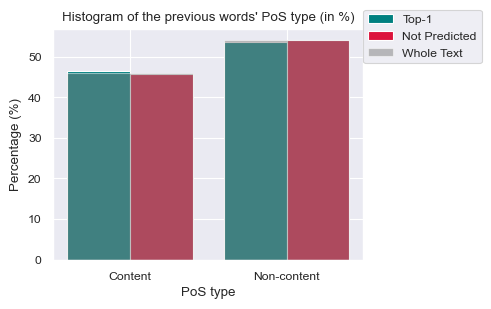

previous PoS_type
Content        46.41713
Non-content    53.58287
Name: proportion, dtype: float64 previous PoS_type
Content        45.767201
Non-content    54.232799
Name: proportion, dtype: float64


In [44]:

# Count and sort alphabetically, then convert to percentages
counts_top1     = words_df[words_df.is_top_1]['previous PoS_type'].value_counts(normalize=True).sort_index() * 100
counts_not_top1 = words_df[~words_df.is_top_1]['previous PoS_type'].value_counts(normalize=True).sort_index() * 100
counts_all      = words_df['previous PoS_type'].value_counts(normalize=True).sort_index() * 100

# Combine the index to cover all POS tags
all_tags = counts_top1.index.union(counts_not_top1.index).union(counts_all.index)
# Reindex to include all tags, filling missing with 0
counts_top1     = counts_top1.reindex(all_tags, fill_value=0)
counts_not_top1 = counts_not_top1.reindex(all_tags, fill_value=0)
counts_all      = counts_all.reindex(all_tags, fill_value=0)
# Plot
plt.figure(figsize=(4,3))
width = 0.4
x = range(len(all_tags))

plt.bar([i - width/2 for i in x], counts_top1, width=width, color='teal', label='Top-1')
plt.bar([i + width/2 for i in x], counts_not_top1, width=width, color='crimson', label='Not Predicted')
plt.bar(x, counts_all, width=width*2, color='gray', alpha=0.5, label='Whole Text') 

plt.xticks(x, all_tags)
plt.xlabel('PoS type')
plt.ylabel('Percentage (%)')
plt.title("Histogram of the previous words' PoS type (in %)")
plt.legend(loc=(1, 0.85))
plt.show()
print(counts_top1, counts_not_top1)

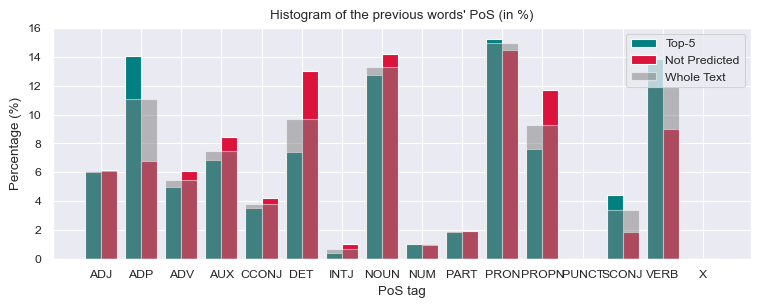

In [50]:

# Count and sort alphabetically, then convert to percentages
counts_top5     = words_df[words_df.is_top_5]['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts_not_top5 = words_df[~words_df.is_top_5]['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts_all      = words_df['previous PoS'].value_counts(normalize=True).sort_index() * 100

# Combine the index to cover all POS tags
all_tags = counts_top5.index.union(counts_not_top5.index).union(counts_all.index)
# Reindex to include all tags, filling missing with 0
counts_top5     = counts_top5.reindex(all_tags, fill_value=0)
counts_not_top5 = counts_not_top5.reindex(all_tags, fill_value=0)
counts_all      = counts_all.reindex(all_tags, fill_value=0)
# Plot
plt.figure(figsize=(9,3))
width = 0.4
x = range(len(all_tags))

plt.bar([i - width/2 for i in x], counts_top5, width=width, color='teal', label='Top-5')
plt.bar([i + width/2 for i in x], counts_not_top5, width=width, color='crimson', label='Not Predicted')
plt.bar(x, counts_all, width=width*2, color='gray', alpha=0.5, label='Whole Text') 

plt.xticks(x, all_tags)
plt.xlabel('PoS tag')
plt.ylabel('Percentage (%)')
plt.title("Histogram of the previous words' PoS (in %)")
plt.legend()
plt.show()

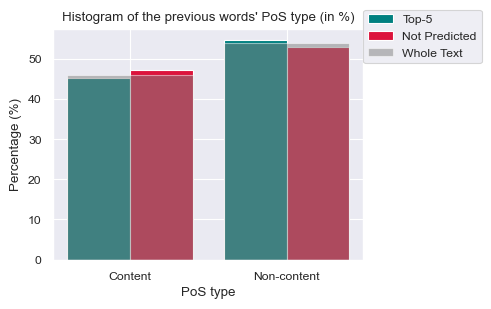

In [51]:
# Count and sort alphabetically, then convert to percentages
counts_top5     = words_df[words_df.is_top_5]['previous PoS_type'].value_counts(normalize=True).sort_index() * 100
counts_not_top5 = words_df[~words_df.is_top_5]['previous PoS_type'].value_counts(normalize=True).sort_index() * 100
counts_all      = words_df['previous PoS_type'].value_counts(normalize=True).sort_index() * 100

# Combine the index to cover all POS tags
all_tags = counts_top5.index.union(counts_not_top5.index).union(counts_all.index)
# Reindex to include all tags, filling missing with 0
counts_top5     = counts_top5.reindex(all_tags, fill_value=0)
counts_not_top5 = counts_not_top5.reindex(all_tags, fill_value=0)
counts_all      = counts_all.reindex(all_tags, fill_value=0)
# Plot
plt.figure(figsize=(4,3))
width = 0.4
x = range(len(all_tags))

plt.bar([i - width/2 for i in x], counts_top5, width=width, color='teal', label='Top-5')
plt.bar([i + width/2 for i in x], counts_not_top5, width=width, color='crimson', label='Not Predicted')
plt.bar(x, counts_all, width=width*2, color='gray', alpha=0.5, label='Whole Text') 

plt.xticks(x, all_tags)
plt.xlabel('PoS type')
plt.ylabel('Percentage (%)')
plt.title("Histogram of the previous words' PoS type (in %)")
plt.legend(loc=(1, 0.85))
plt.show()

In [45]:
if dataset in ['Armeni', 'Gwilliams']:
    y = y_acoustics

    X_Glove_top_1     = X_Glove[is_top_1]
    X_Glove_top_5     = X_Glove[is_top_5]
    X_Glove_not_top_1 = X_Glove[is_not_top_1]
    X_Glove_not_top_5 = X_Glove[is_not_top_5]

    y_top_1     = y[is_top_1]
    y_top_5     = y[is_top_5]
    y_not_top_1 = y[is_not_top_1]
    y_not_top_5 = y[is_not_top_5]

    y_top_1 = np.swapaxes(np.swapaxes(y_top_1, 1, 2), 0, 1)
    y_top_5 = np.swapaxes(np.swapaxes(y_top_5, 1, 2), 0, 1)
    y_not_top_1 = np.swapaxes(np.swapaxes(y_not_top_1, 1, 2), 0, 1)
    y_not_top_5 = np.swapaxes(np.swapaxes(y_not_top_5, 1, 2), 0, 1)

In [46]:
if dataset in ['Armeni', 'Gwilliams']:
    # compute the encoding of the acoustics for each split
    encoding_Glove_top_1     = brainscore(X_Glove_top_1, y_top_1)
    encoding_Glove_not_top_1 = brainscore(X_Glove_not_top_1, y_not_top_1)

We are now in the brainscore method, and y has shape:
(9, 30590, 157)
We are now in the brainscore method, and y has shape:
(9, 55129, 157)


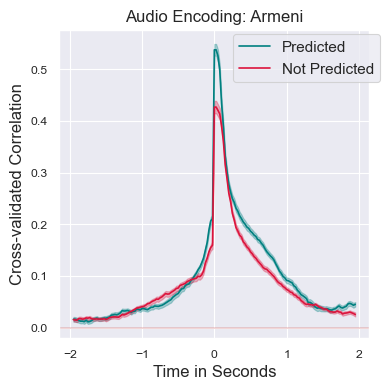

In [47]:
if dataset in ['Armeni', 'Gwilliams']:
    models = ['Top 1', 'Not Predicted']
    labels = ['Predicted', 'Not Predicted']
        
        
    fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

    for i, key in enumerate([encoding_Glove_top_1, encoding_Glove_not_top_1]):
        ax1.plot(times_100, key.mean(axis=0).mean(axis=0), c=colours[models[i]], label=labels[i])   
        ax1.fill_between(times_100, lowerCI(reshape(key)), 
                                    upperCI(reshape(key)), color=colours[models[i]], alpha=0.3)

    ax1.legend(fontsize=11, loc=(0.56, 0.83))
    ax1.set_xlabel('Time in Seconds', fontsize=12)
    ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
    ax1.axhline(c='indianred',  alpha=0.3)
    ax1.set_title('Audio Encoding: ' + dataset, fontsize=12)

#### Since we see that there are differences in PoS types accross the two categories & a difference in the number of trials, which might both affect encoding performance, we account for both in the predictability split:

We do this in the following way:
--------------------------------
1. We compute the PoS distribution in the entire texts 

2. We randomly subsample the Top-1 & Top-5 splits such that they best ressemble the PoS distribution in the whole text. Since this comes with a loss of trials, we try to maximise the number of trials without deviating from the desired PoS distribution by as little as possible in any of the main PoS: Noun, Verb, Adjective etc. The subsampling avoids chucking out locally highly predictable trials, i.e. bigrams in the text

3. The Not-Predicted split is then randomly subsambled such that it has the same number of trials and PoS distribution as the Top-1/Top-5 split

4. This is done for 100 random seeds and averaged 

In [28]:
len(words_df[words_df.is_top_1][words_df.is_bigram]), len(words_df[words_df.is_top_1][~words_df.is_bigram])

/var/folders/0s/rfyt86_x3dd79y121cm9vtrr0000gn/T/ipykernel_42241/3960561059.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(words_df[words_df.is_top_1][words_df.is_bigram]), len(words_df[words_df.is_top_1][~words_df.is_bigram])
/var/folders/0s/rfyt86_x3dd79y121cm9vtrr0000gn/T/ipykernel_42241/3960561059.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(words_df[words_df.is_top_1][words_df.is_bigram]), len(words_df[words_df.is_top_1][~words_df.is_bigram])


(701, 784)

In [29]:
len(words_df[words_df.is_top_5][words_df.is_bigram]), len(words_df[words_df.is_top_5][~words_df.is_bigram])

/var/folders/0s/rfyt86_x3dd79y121cm9vtrr0000gn/T/ipykernel_42241/3836302637.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(words_df[words_df.is_top_5][words_df.is_bigram]), len(words_df[words_df.is_top_5][~words_df.is_bigram])
/var/folders/0s/rfyt86_x3dd79y121cm9vtrr0000gn/T/ipykernel_42241/3836302637.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(words_df[words_df.is_top_5][words_df.is_bigram]), len(words_df[words_df.is_top_5][~words_df.is_bigram])


(1082, 1522)

In [32]:

# Split the dataframe
df_top1     = words_df[words_df['is_top_1']].copy()
df_not_top1 = words_df[~words_df['is_top_1']].copy()

# Set target sizes
if dataset == 'Goldstein':
        target_size_top1     = 800 # this size keeps the PoS distribution fairly balanced (+/- 0.16%)
        target_size_not_top1 = 800
elif dataset == 'Armeni':
        target_size_top1     = 2500
        target_size_not_top1 = 2500
elif dataset == 'Gwilliams':
        target_size_top1     = 1000
        target_size_not_top1 = 1000
#target_size_not_top1 = target_size_top1 # keep them equal

# get the percentages in the whole text
PoS_percentage_whole_text  = words_df['previous PoS'].value_counts(normalize=True).sort_index() * 100

# Subsample without replacement
sub_top1              = subsample_to_adjust_PoS(df_top1, PoS_percentage_whole_text, target_size_top1, random_state=41, keep_bigrams=True)
PoS_percentage_top1   = sub_top1['previous PoS'].value_counts(normalize=True).sort_index() * 100
sub_not_top1          = subsample_to_adjust_PoS(df_not_top1, PoS_percentage_top1, target_size_not_top1, random_state=41, keep_bigrams=False)

# Check resulting distributions
print(dataset,': \n', '-'*41)
print('\t All \t Top-1 \t Not Top-1  Diff  \n', '-'*41)
for indx, all, top1, not_top1 in zip(words_df['previous PoS'].value_counts(normalize=True).index, 
                                     words_df['previous PoS'].value_counts(normalize=True) * 100, 
                             sub_top1['previous PoS'].value_counts(normalize=True) * 100, 
                             sub_not_top1['previous PoS'].value_counts(normalize=True) * 100):
    print('{}: \t {:.2f} \t {:.2f} \t {:.2f} \t ({:.2f})'.format(indx, all, top1, not_top1, (not_top1-top1)))


Goldstein : 
 -----------------------------------------
	 All 	 Top-1 	 Not Top-1  Diff  
 -----------------------------------------
NOUN: 	 17.76 	 16.57 	 16.67 	 (0.10)
PRON: 	 14.02 	 16.45 	 16.54 	 (0.09)
VERB: 	 13.32 	 13.07 	 13.13 	 (0.06)
ADP: 	 10.48 	 12.37 	 12.37 	 (0.01)
DET: 	 9.99 	 10.15 	 10.23 	 (0.08)
AUX: 	 6.00 	 5.48 	 5.43 	 (-0.05)
PROPN: 	 5.88 	 5.48 	 5.43 	 (-0.05)
ADV: 	 5.14 	 4.78 	 4.80 	 (0.01)
ADJ: 	 4.93 	 4.55 	 4.55 	 (-0.01)
CCONJ: 	 3.76 	 3.62 	 3.54 	 (-0.08)
SCONJ: 	 2.77 	 3.03 	 3.03 	 (-0.00)
PART: 	 2.45 	 2.33 	 2.27 	 (-0.06)
INTJ: 	 2.10 	 1.17 	 1.14 	 (-0.03)
NUM: 	 1.36 	 0.93 	 0.88 	 (-0.05)


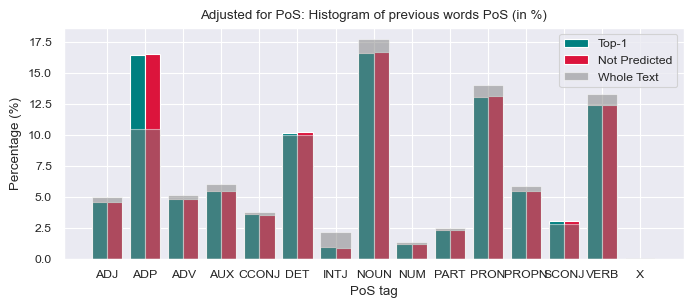

In [32]:

# Count and sort alphabetically, then convert to percentages
counts1 = sub_top1['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts2 = sub_not_top1['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts3  = words_df['previous PoS'].value_counts(normalize=True).sort_index() * 100

# Combine the index to cover all POS tags
all_tags = counts1.index.union(counts2.index).union(counts3.index)

# Reindex to include all tags, filling missing with 0
counts1 = counts1.reindex(all_tags, fill_value=0)
counts2 = counts2.reindex(all_tags, fill_value=0)
counts3 = counts3.reindex(all_tags, fill_value=0)

# Plot
plt.figure(figsize=(8,3))
width = 0.4
x = range(len(all_tags))

plt.bar([i - width/2 for i in x], counts1, width=width, color='teal', label='Top-1')
plt.bar([i + width/2 for i in x], counts2, width=width, color='crimson', label='Not Predicted')
plt.bar(x, counts3, width=width*2, color='gray', alpha=0.5, label='Whole Text') 

plt.xticks(x, all_tags)
plt.xlabel('PoS tag')
plt.ylabel('Percentage (%)')
plt.title('Adjusted for PoS: Histogram of previous words PoS (in %)')
plt.legend()
plt.show()

In [33]:

# Subsample and encode for 100 different random states:
# -----------------------------------------------------

# initialise lists for encodings:
list_top1     = []
list_not_top1 = []

for i in range(100):
    # Subsample without replacement
    sub_top1     = subsample_to_adjust_PoS(df_top1, PoS_percentage_whole_text, target_size_top1, random_state=i, keep_bigrams=True)
    PoS_percentage_top1   = sub_top1['previous PoS'].value_counts(normalize=True).sort_index() * 100
    sub_not_top1 = subsample_to_adjust_PoS(df_not_top1, PoS_percentage_top1, target_size_not_top1, random_state=i, keep_bigrams=False)

    # get the indices:
    indx_top_1     = sub_top1.word_index.to_numpy().astype(int)
    indx_not_top_1 = sub_not_top1.word_index.to_numpy().astype(int)

    # split and format the y matrix:
    y           = y_acoustics
    y_top_1     = y[indx_top_1]
    y_not_top_1 = y[indx_not_top_1]
    y_top_1     = np.swapaxes(np.swapaxes(y_top_1, 1, 2), 0, 1)
    y_not_top_1 = np.swapaxes(np.swapaxes(y_not_top_1, 1, 2), 0, 1)

    # split the X_Glove matrix
    X_Glove_top_1     = X_Glove[indx_top_1]
    X_Glove_not_top_1 = X_Glove[indx_not_top_1]


    # compute the encoding of the acoustics for each split
    encoding_Glove_top_1     = brainscore(X_Glove_top_1, y_top_1)
    encoding_Glove_not_top_1 = brainscore(X_Glove_not_top_1, y_not_top_1)

    list_top1.append(encoding_Glove_top_1)
    list_not_top1.append(encoding_Glove_not_top_1)

# concatenate along the 1st axis since our plotting routing reshapes the data anyway but expects 3 dimensions
encoding_Glove_top_1     = np.concatenate(list_top1, axis=0)
encoding_Glove_not_top_1 = np.concatenate(list_not_top1, axis=0)

encoding_Glove_top_1.shape

We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has shape:
(9, 857, 157)
We are now in the brainscore method, and y has shape:
(9, 792, 157)
We are now in the brainscore method, and y has s

(900, 10, 157)

Text(0.5, 1.0, 'Goldstein Audio Encoding: \n PoS adjusted: Original Vectors Top 1')

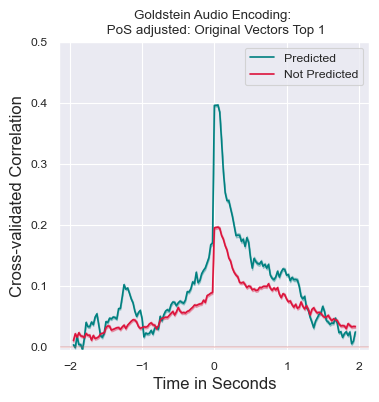

In [34]:
models = ['Top 1', 'Not Predicted']
labels = ['Predicted', 'Not Predicted']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_top_1, encoding_Glove_not_top_1]):
    ax1.plot(times_100, key.mean(axis=0).mean(axis=0), c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100, lowerCI(reshape(key)), 
                                upperCI(reshape(key)), color=colours[models[i]], alpha=0.3)

ax1.legend()
ax1.set_ylim([-0.005, 0.5])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Original Vectors ' + models[0])

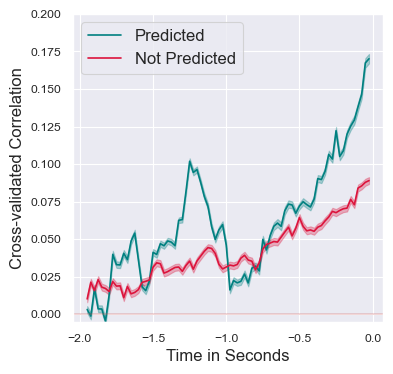

In [59]:
models = ['Top 1', 'Not Predicted']
labels = ['Predicted', 'Not Predicted']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_top_1, encoding_Glove_not_top_1]):
    ax1.plot(times_100[:78], key.mean(axis=0).mean(axis=0)[:78], c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100[:78], lowerCI(reshape(key))[:78], 
                                upperCI(reshape(key))[:78], color=colours[models[i]], alpha=0.3)

ax1.legend(fontsize=12)
ax1.set_ylim([-0.005, 0.2])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
#ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Original Vectors ' + models[0])


use_regressed_out= False
plot_split       = True
top              = 1

fig_path = fig_folder+'Acoustics_{}_with_residualised_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)

plt.savefig(fig_path, format='pdf',bbox_inches='tight')

...now let's do this for the Top-5 split


In [37]:

# Split the dataframe
df_top5     = words_df[words_df['is_top_5']].copy()
df_not_top5 = words_df[~words_df['is_top_5']][~words_df['is_bigram']].copy()

# Set target sizes
if dataset == 'Goldstein':
        target_size_top5     = 1500 # this number keeps the PoS distribution balanced (+/- 0.1%)
elif dataset == 'Armeni':
        target_size_top5     = 2500 # this number keeps the PoS distribution balanced (+/- 0.1%)
elif dataset == 'Gwilliams':
        target_size_top5     = 1850
target_size_not_top5 = target_size_top5 # keep them equal

# get the percentages in the whole text
PoS_percentage_whole_text  = words_df['previous PoS'].value_counts(normalize=True).sort_index() * 100

# Subsample without replacement
sub_top5             = subsample_to_adjust_PoS(df_top5, PoS_percentage_whole_text, target_size_top5, random_state=31, keep_bigrams=True)
PoS_percentage_top5  = sub_top5['previous PoS'].value_counts(normalize=True).sort_index() * 100
sub_not_top5         = subsample_to_adjust_PoS(df_not_top5, PoS_percentage_top5, target_size_not_top5, random_state=31, keep_bigrams=False)

# Check resulting distributions
print(dataset,': \n', '-'*41)
print('\t All \t Top-5 \t Not Top-5  Diff  \n', '-'*41)
for indx, all, top5, not_top5 in zip(words_df['previous PoS'].value_counts(normalize=True).index, 
                                     words_df['previous PoS'].value_counts(normalize=True) * 100, 
                             sub_top5['previous PoS'].value_counts(normalize=True) * 100, 
                             sub_not_top5['previous PoS'].value_counts(normalize=True) * 100):
    print('{}: \t {:.2f} \t {:.2f} \t {:.2f} \t ({:.2f})'.format(indx, all, top5, not_top5, (not_top5-top5)))

Goldstein : 
 -----------------------------------------
	 All 	 Top-5 	 Not Top-5  Diff  
 -----------------------------------------
NOUN: 	 17.76 	 17.12 	 18.02 	 (0.90)
PRON: 	 14.02 	 14.41 	 14.22 	 (-0.20)
VERB: 	 13.32 	 13.51 	 13.51 	 (-0.00)
ADP: 	 10.48 	 12.81 	 10.13 	 (-2.67)
DET: 	 9.99 	 9.59 	 10.06 	 (0.48)
AUX: 	 6.00 	 5.73 	 5.98 	 (0.25)
PROPN: 	 5.88 	 5.66 	 5.91 	 (0.25)
ADV: 	 5.14 	 4.95 	 5.21 	 (0.25)
ADJ: 	 4.93 	 4.70 	 4.93 	 (0.23)
CCONJ: 	 3.76 	 3.60 	 3.80 	 (0.20)
SCONJ: 	 2.77 	 2.64 	 2.74 	 (0.11)
PART: 	 2.45 	 2.32 	 2.39 	 (0.08)
INTJ: 	 2.10 	 1.67 	 1.76 	 (0.09)
NUM: 	 1.36 	 1.29 	 1.34 	 (0.05)


/var/folders/0s/rfyt86_x3dd79y121cm9vtrr0000gn/T/ipykernel_42241/2000979510.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_not_top5 = words_df[~words_df['is_top_5']][~words_df['is_bigram']].copy()


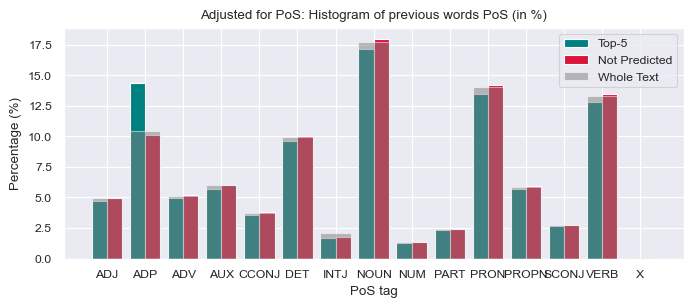

In [38]:

# Count and sort alphabetically, then convert to percentages
counts1 = sub_top5['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts2 = sub_not_top5['previous PoS'].value_counts(normalize=True).sort_index() * 100
counts3 = words_df['previous PoS'].value_counts(normalize=True).sort_index() * 100

# Combine the index to cover all POS tags
all_tags = counts1.index.union(counts2.index).union(counts3.index)

# Reindex to include all tags, filling missing with 0
counts1 = counts1.reindex(all_tags, fill_value=0)
counts2 = counts2.reindex(all_tags, fill_value=0)
counts3 = counts3.reindex(all_tags, fill_value=0)

# Plot
plt.figure(figsize=(8,3))
width = 0.4
x = range(len(all_tags))

plt.bar([i - width/2 for i in x], counts1, width=width, color='teal', label='Top-5')
plt.bar([i + width/2 for i in x], counts2, width=width, color='crimson', label='Not Predicted')
plt.bar(x, counts3, width=width*2, color='gray', alpha=0.5, label='Whole Text') 

plt.xticks(x, all_tags)
plt.xlabel('PoS tag')
plt.ylabel('Percentage (%)')
plt.title('Adjusted for PoS: Histogram of previous words PoS (in %)')
plt.legend()
plt.show()

In [39]:

# Subsample and encode for 100 different random states:
# -----------------------------------------------------

# initialise lists for encodings:
list_top5     = []
list_not_top5 = []

for i in range(100):
    # Subsample without replacement
    sub_top5     = subsample_to_adjust_PoS(df_top5, PoS_percentage_whole_text, target_size_top5, random_state=i, keep_bigrams=True)
    sub_not_top5 = subsample_to_adjust_PoS(df_not_top5, PoS_percentage_whole_text, target_size_not_top5, random_state=i, keep_bigrams=False)

    # get the indices:
    indx_top_5     = sub_top5.word_index.to_numpy().astype(int)
    indx_not_top_5 = sub_not_top5.word_index.to_numpy().astype(int)

    # split and format the y matrix:
    y           = y_acoustics
    y_top_5     = y[indx_top_5]
    y_not_top_5 = y[indx_not_top_5]
    y_top_5     = np.swapaxes(np.swapaxes(y_top_5, 1, 2), 0, 1)
    y_not_top_5 = np.swapaxes(np.swapaxes(y_not_top_5, 1, 2), 0, 1)

    # split the X_Glove matrix
    X_Glove_top_5     = X_Glove[indx_top_5]
    X_Glove_not_top_5 = X_Glove[indx_not_top_5]


    # compute the encoding of the acoustics for each split
    encoding_Glove_top_5     = brainscore(X_Glove_top_5, y_top_5)
    encoding_Glove_not_top_5 = brainscore(X_Glove_not_top_5, y_not_top_5)

    list_top5.append(encoding_Glove_top_5)
    list_not_top5.append(encoding_Glove_not_top_5)

# concatenate along the 1st axis since our plotting routing reshapes the data anyway but expects 3 dimensions
encoding_Glove_top_5     = np.concatenate(list_top5, axis=0)
encoding_Glove_not_top_5 = np.concatenate(list_not_top5, axis=0)
encoding_Glove_top_5.shape

We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore method, and y has shape:
(9, 1554, 157)
We are now in the brainscore method, and y has shape:
(9, 1480, 157)
We are now in the brainscore metho

(900, 10, 157)

Text(0.5, 1.0, 'Goldstein Audio Encoding: \n PoS adjusted: Original Vectors Top 5')

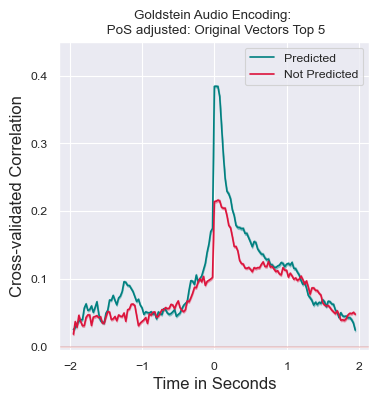

In [40]:
models = ['Top 5', 'Not Predicted']
labels = ['Predicted', 'Not Predicted']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_top_5, encoding_Glove_not_top_5]):
    ax1.plot(times_100, key.mean(axis=0).mean(axis=0), c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100, lowerCI(reshape(key)), 
                                upperCI(reshape(key)), color=colours[models[i]], alpha=0.3)

ax1.legend()
ax1.set_ylim([-0.005, 0.45])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Original Vectors ' + models[0])

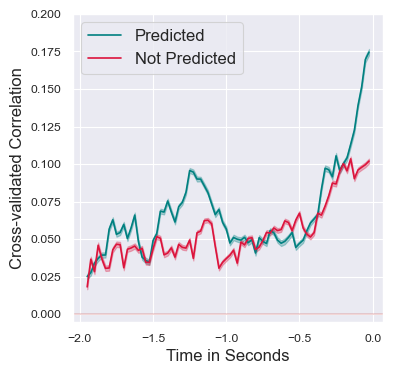

In [60]:
models = ['Top 5', 'Not Predicted']
labels = ['Predicted', 'Not Predicted']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_top_5, encoding_Glove_not_top_5]):
    ax1.plot(times_100[:78], key.mean(axis=0).mean(axis=0)[:78], c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100[:78], lowerCI(reshape(key))[:78], 
                                upperCI(reshape(key))[:78], color=colours[models[i]], alpha=0.3)

ax1.legend(fontsize=12)
ax1.set_ylim([-0.005, 0.2])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
#ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Original Vectors ' + models[0])


use_regressed_out= False
plot_split       = True
top              = 5

fig_path = fig_folder+'Acoustics_{}_with_residualised_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)
plt.savefig(fig_path, format='pdf',bbox_inches='tight')

### Now we look at residualised GloVe vectors:

In [ ]:
print(y.shape)

(5136, 157, 9)


In [42]:

# Subsample and encode for 100 different random states:
# -----------------------------------------------------

# initialise lists for encodings:
list_top1_residualised     = []
list_not_top1_residualised = []

for i in range(100):
    # Subsample without replacement
    sub_top1     = subsample_to_adjust_PoS(df_top1, PoS_percentage_whole_text, target_size_top1, random_state=i, keep_bigrams=True)
    PoS_percentage_top1   = sub_top1['previous PoS'].value_counts(normalize=True).sort_index() * 100
    sub_not_top1 = subsample_to_adjust_PoS(df_not_top1, PoS_percentage_top1, target_size_not_top1, random_state=i, keep_bigrams=False)


    # make sure y is still 
    y  = y_acoustics # we do not drop the 1st epoch since it's inside the new method
    y  = np.swapaxes(np.swapaxes(y, 1, 2), 0, 1)
    print(y.shape)

    # compute the encoding of the acoustics for each split
    encoding_Glove_residualised_top_1     = brainscore(X_Glove, y, indx_top_1 = indx_top_1)
    encoding_Glove_residualised_not_top_1 = brainscore(X_Glove, y, indx_top_1 = indx_not_top_1)

    list_top1_residualised.append(encoding_Glove_residualised_top_1)
    list_not_top1_residualised.append(encoding_Glove_residualised_not_top_1)

# concatenate along the 1st axis since our plotting routing reshapes the data anyway but expects 3 dimensions
encoding_Glove_residualised_top_1     = np.concatenate(list_top1_residualised, axis=0)
encoding_Glove_residualised_not_top_1 = np.concatenate(list_not_top1_residualised, axis=0)
encoding_Glove_residualised_top_1.shape

(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157

(900, 10, 157)

Text(0.5, 1.0, 'Goldstein Audio Encoding: \n PoS adjusted: Residualised Vectors Top 1')

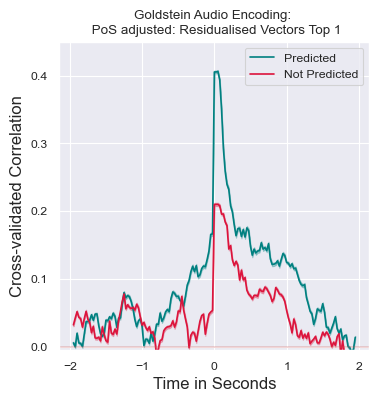

In [43]:
models = ['Top 1', 'Not Predicted']
labels = ['Predicted', 'Not Predicted']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_residualised_top_1, encoding_Glove_residualised_not_top_1]):
    ax1.plot(times_100, key.mean(axis=0).mean(axis=0), c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100, lowerCI(reshape(key)), 
                                upperCI(reshape(key)), color=colours[models[i]], alpha=0.3)

ax1.legend()
ax1.set_ylim([-0.005, 0.45])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Residualised Vectors ' + models[0])

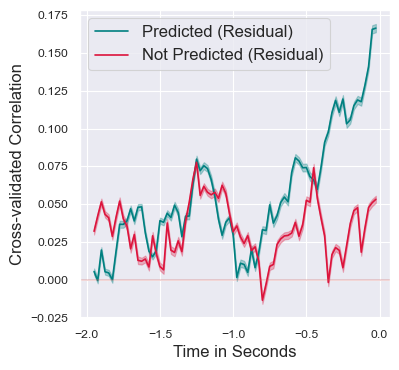

In [61]:
models = ['Top 1', 'Not Predicted']
labels = ['Predicted (Residual)', 'Not Predicted (Residual)']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_residualised_top_1, encoding_Glove_residualised_not_top_1]):
    ax1.plot(times_100[:78], key.mean(axis=0).mean(axis=0)[:78], c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100[:78], lowerCI(reshape(key))[:78], 
                                upperCI(reshape(key))[:78], color=colours[models[i]], alpha=0.3)

ax1.legend(fontsize=12)
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
#ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Residualised Vectors ' + models[0])

use_regressed_out= True
plot_split       = True
top              = 1

fig_path = fig_folder+'Acoustics_{}_with_residualised_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)
plt.savefig(fig_path, format='pdf',bbox_inches='tight')

In [45]:

# Subsample and encode for 100 different random states:
# -----------------------------------------------------

# initialise lists for encodings:
list_top5_residualised     = []
list_not_top5_residualised = []

for i in range(100):
    # Subsample without replacement
    sub_top5     = subsample_to_adjust_PoS(df_top5, PoS_percentage_whole_text, target_size_top5, random_state=i, keep_bigrams=True)
    PoS_percentage_top5   = sub_top5['previous PoS'].value_counts(normalize=True).sort_index() * 100
    sub_not_top5 = subsample_to_adjust_PoS(df_not_top5, PoS_percentage_top5, target_size_not_top5, random_state=i, keep_bigrams=False)


    # make sure y is still 
    y  = y_acoustics # we do not drop the 1st epoch since it's inside the new method
    y  = np.swapaxes(np.swapaxes(y, 1, 2), 0, 1)
    print(y.shape)

    # compute the encoding of the acoustics for each split
    encoding_Glove_residualised_top_5     = brainscore(X_Glove, y, indx_top_1 = indx_top_5)
    encoding_Glove_residualised_not_top_5 = brainscore(X_Glove, y, indx_top_1 = indx_not_top_5)

    list_top5_residualised.append(encoding_Glove_residualised_top_5)
    list_not_top5_residualised.append(encoding_Glove_residualised_not_top_5)

# concatenate along the 1st axis since our plotting routing reshapes the data anyway but expects 3 dimensions
encoding_Glove_residualised_top_5     = np.concatenate(list_top5_residualised, axis=0)
encoding_Glove_residualised_not_top_5 = np.concatenate(list_not_top5_residualised, axis=0)
encoding_Glove_residualised_top_5.shape

(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157)
(9, 5136, 157)
We are now in the brainscore method, and y has shape:
(9, 5136, 157

(900, 10, 157)

Text(0.5, 1.0, 'Goldstein Audio Encoding: \n PoS adjusted: Residualised Vectors Top 5')

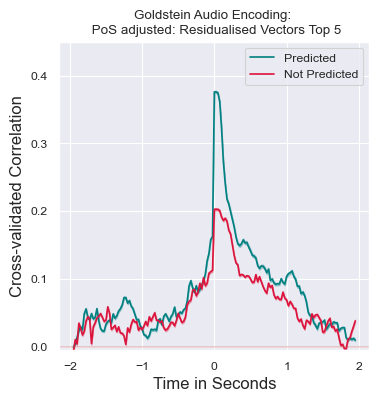

In [46]:
models = ['Top 5', 'Not Predicted']
labels = ['Predicted', 'Not Predicted']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_residualised_top_5, encoding_Glove_residualised_not_top_5]):
    ax1.plot(times_100, key.mean(axis=0).mean(axis=0), c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100, lowerCI(reshape(key)), 
                                upperCI(reshape(key)), color=colours[models[i]], alpha=0.3)

ax1.legend()
ax1.set_ylim([-0.005, 0.45])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Residualised Vectors ' + models[0])

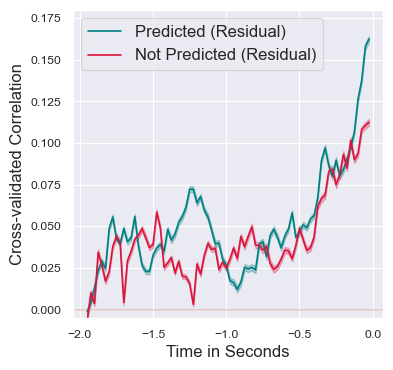

In [62]:
models = ['Top 5', 'Not Predicted']
labels = ['Predicted (Residual)', 'Not Predicted (Residual)']
    
    
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 4))

for i, key in enumerate([encoding_Glove_residualised_top_5, encoding_Glove_residualised_not_top_5]):
    ax1.plot(times_100[:78], key.mean(axis=0).mean(axis=0)[:78], c=colours[models[i]], label=labels[i])   
    ax1.fill_between(times_100[:78], lowerCI(reshape(key))[:78], 
                                upperCI(reshape(key))[:78], color=colours[models[i]], alpha=0.3)

ax1.legend(fontsize=12)
ax1.set_ylim([-0.005, 0.18])
ax1.set_xlabel('Time in Seconds', fontsize=12)
ax1.set_ylabel('Cross-validated Correlation', fontsize=12)
ax1.axhline(c='indianred',  alpha=0.3)
#ax1.set_title(dataset+' Audio Encoding: \n PoS adjusted: Residualised Vectors ' + models[0])

use_regressed_out= True
plot_split       = True
top              = 5

fig_path = fig_folder+'Acoustics_{}_with_residualised_vectors_{}-prediction_split_{}-top_{}.pdf'.format(dataset,
                                                                                                  use_regressed_out,
                                                                                                  plot_split, 
                                                                                                  top)
plt.savefig(fig_path, format='pdf',bbox_inches='tight')

In [48]:
fig_path

'../figures/supplementary/Acoustics_Goldstein_with_residualised_vectors_True-prediction_split_True-top_5.pdf'